In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/predictive_maintenance_raw.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [8]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [9]:
df['Machine failure'].value_counts(normalize=True)

,proportion
Machine failure,
0,0.9661
1,0.0339


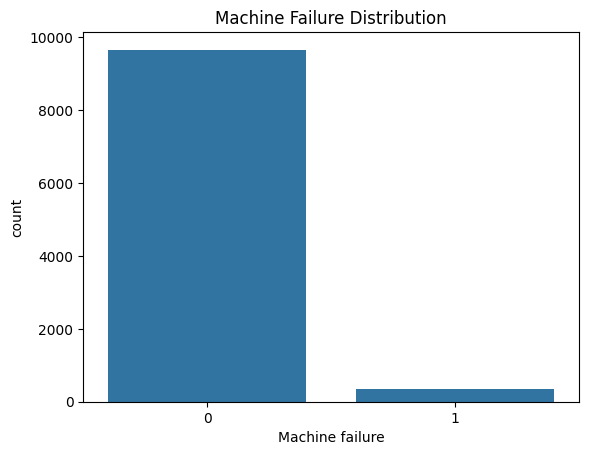

In [10]:
sns.countplot(x='Machine failure', data=df)
plt.title('Machine Failure Distribution')
plt.show()

In [11]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


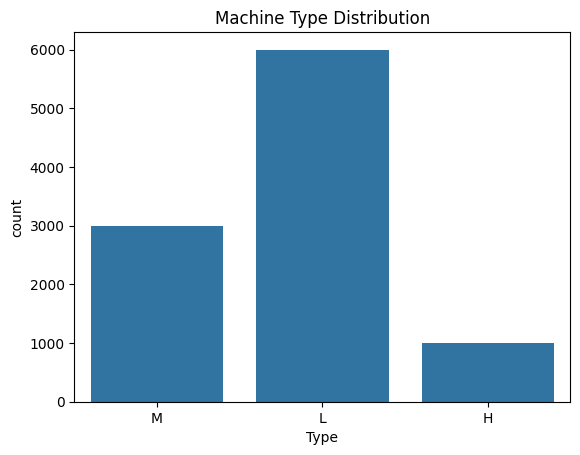

In [12]:
sns.countplot(x='Type', data=df)
plt.title('Machine Type Distribution')
plt.show()

In [13]:
pd.crosstab(df['Type'], df['Machine failure'])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


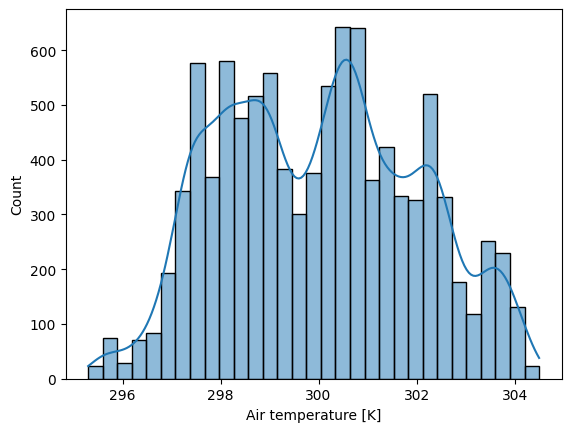

In [14]:
sns.histplot(df['Air temperature [K]'], kde=True)
plt.show()

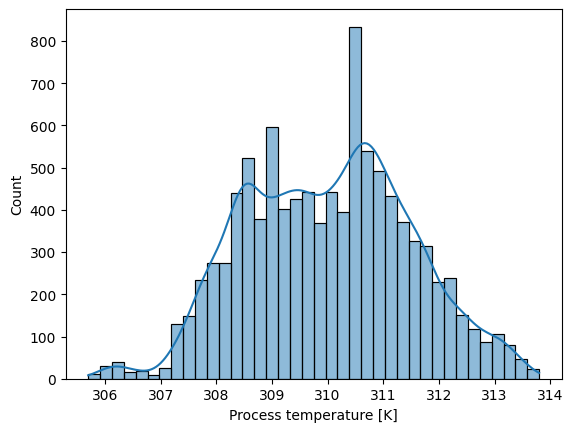

In [15]:
sns.histplot(df['Process temperature [K]'], kde=True)
plt.show()

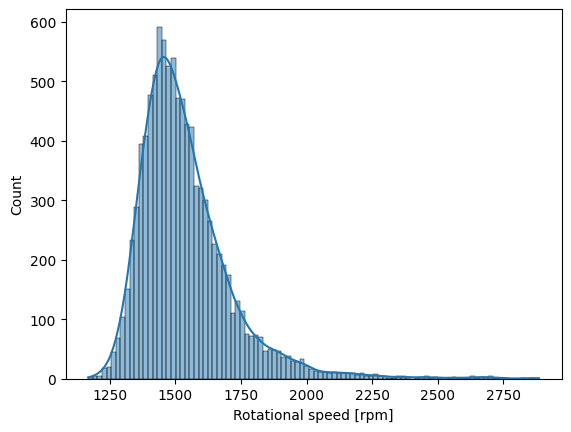

In [16]:
sns.histplot(df['Rotational speed [rpm]'], kde=True)
plt.show()

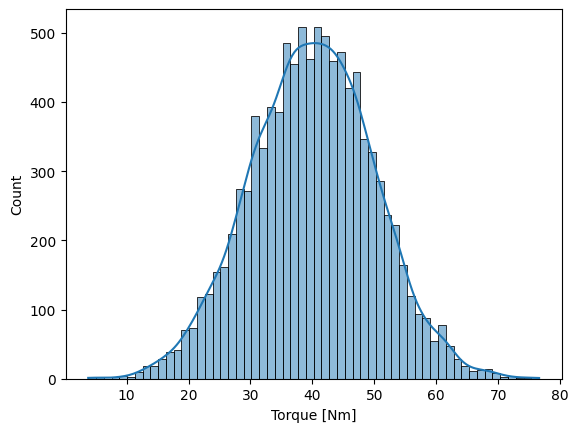

In [17]:
sns.histplot(df['Torque [Nm]'], kde=True)
plt.show()

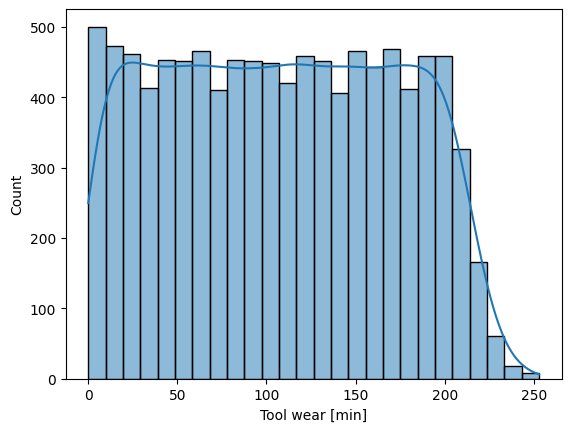

In [18]:
sns.histplot(df['Tool wear [min]'], kde=True)
plt.show()

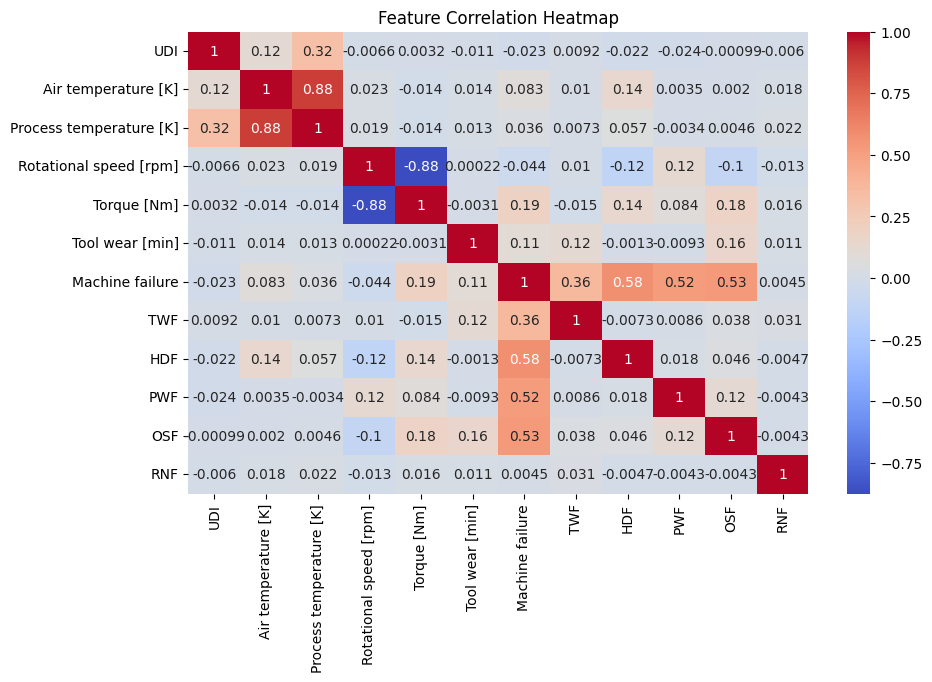

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

In [20]:
df_model = df.copy()

In [21]:
df_model = df_model.drop(columns=[
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
])

In [22]:
df_model.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [23]:
df_model = pd.get_dummies(df_model,
                          columns=['Type'],
                          drop_first=True)

In [24]:
X = df_model.drop('Machine failure', axis=1)

y = df_model['Machine failure']

In [25]:
X.shape

(10000, 7)

In [26]:
y.shape

(10000,)

In [27]:
y.value_counts()

,count
Machine failure,
0,9661
1,339


In [28]:
y.value_counts(normalize=True)

,proportion
Machine failure,
0,0.9661
1,0.0339


In [31]:
df_model.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,True,False
2,298.1,308.5,1498,49.4,5,0,True,False
3,298.2,308.6,1433,39.5,7,0,True,False
4,298.2,308.7,1408,40.0,9,0,True,False


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
y_train.value_counts(normalize=True)

,proportion
Machine failure,
0,0.966125
1,0.033875


In [35]:
y_test.value_counts(normalize=True)

,proportion
Machine failure,
0,0.966
1,0.034


In [36]:
from sklearn.linear_model import LogisticRegression

In [38]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
y_pred = baseline_model.predict(X_test)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [41]:
accuracy_score(y_test, y_pred)

0.9685

In [42]:
precision_score(y_test, y_pred)

0.6666666666666666

In [43]:
recall_score(y_test, y_pred)

0.14705882352941177

In [44]:
f1_score(y_test, y_pred)

0.24096385542168675

In [45]:
confusion_matrix(y_test, y_pred)

array([[1927,    5],
       [  58,   10]])

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.67      0.15      0.24        68

    accuracy                           0.97      2000
   macro avg       0.82      0.57      0.61      2000
weighted avg       0.96      0.97      0.96      2000



In [47]:
pip install xgboost

In [48]:
from xgboost import XGBClassifier

In [49]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

scale_pos_weight

28.52029520295203

In [51]:
X_train.columns = X_train.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test.columns = X_test.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [52]:
y_pred_xgb = xgb_model.predict(X_test)

In [53]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.40      0.85      0.55        68

    accuracy                           0.95      2000
   macro avg       0.70      0.90      0.76      2000
weighted avg       0.97      0.95      0.96      2000



In [54]:
confusion_matrix(y_test, y_pred_xgb)

array([[1846,   86],
       [  10,   58]])

In [55]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,Rotational speed _rpm_,0.347443
4,Tool wear _min_,0.241849
3,Torque _Nm_,0.238025
0,Air temperature _K_,0.079646
1,Process temperature _K_,0.048054
6,Type_M,0.033941
5,Type_L,0.011042


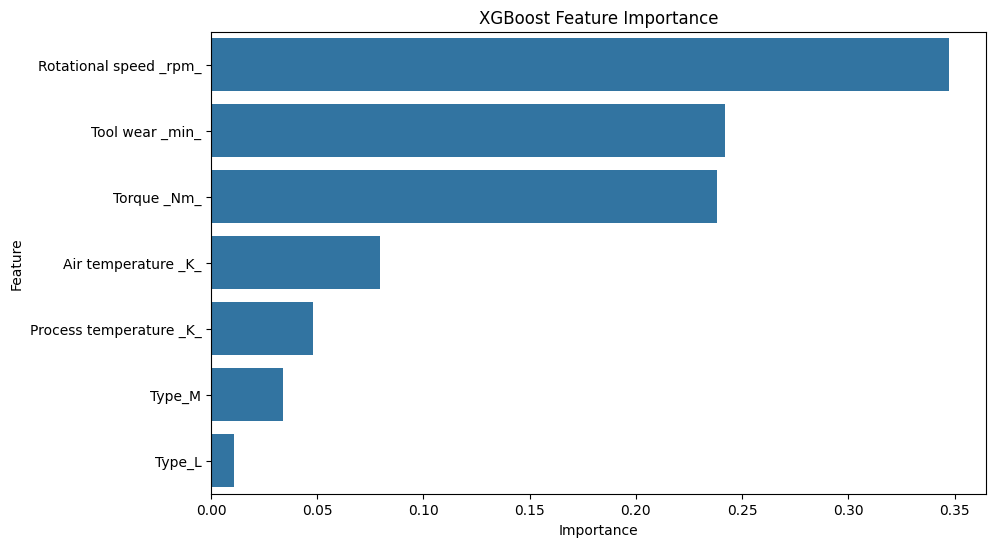

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('XGBoost Feature Importance')
plt.show()

In [57]:
df_model['Temp_diff'] = (
    df_model['Process temperature [K]']
    - df_model['Air temperature [K]']
)

In [58]:
df_model['Power_proxy'] = (
    df_model['Rotational speed [rpm]']
    * df_model['Torque [Nm]']
)

In [59]:
df_model['Wear_Torque_Interaction'] = (
    df_model['Tool wear [min]']
    * df_model['Torque [Nm]']
)

In [60]:
df_model['Speed_Temp_Interaction'] = (
    df_model['Rotational speed [rpm]']
    * df_model['Process temperature [K]']
)

In [61]:
X = df_model.drop('Machine failure', axis=1)

y = df_model['Machine failure']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
# ================================
# STEP 7 — ADVANCED FEATURE ENGINEERING
# ================================

# Create a fresh copy
df_engineered = df_model.copy()

# --------------------------------
# 1. Temperature Difference
# --------------------------------
df_engineered['Temp_diff'] = (
    df_engineered['Process temperature [K]']
    - df_engineered['Air temperature [K]']
)

# --------------------------------
# 2. Power Proxy Feature
# --------------------------------
df_engineered['Power_proxy'] = (
    df_engineered['Rotational speed [rpm]']
    * df_engineered['Torque [Nm]']
)

# --------------------------------
# 3. Wear-Torque Interaction
# --------------------------------
df_engineered['Wear_Torque_Interaction'] = (
    df_engineered['Tool wear [min]']
    * df_engineered['Torque [Nm]']
)

# --------------------------------
# 4. Speed-Temperature Interaction
# --------------------------------
df_engineered['Speed_Temp_Interaction'] = (
    df_engineered['Rotational speed [rpm]']
    * df_engineered['Process temperature [K]']
)

# --------------------------------
# View New Columns
# --------------------------------
df_engineered.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,Temp_diff,Power_proxy,Wear_Torque_Interaction,Speed_Temp_Interaction
0,298.1,308.6,1551,42.8,0,0,False,True,10.5,66382.8,0.0,478638.6
1,298.2,308.7,1408,46.3,3,0,True,False,10.5,65190.4,138.9,434649.6
2,298.1,308.5,1498,49.4,5,0,True,False,10.4,74001.2,247.0,462133.0
3,298.2,308.6,1433,39.5,7,0,True,False,10.4,56603.5,276.5,442223.8
4,298.2,308.7,1408,40.0,9,0,True,False,10.5,56320.0,360.0,434649.6


In [65]:
# ================================
# Rebuild X and y
# ================================

X = df_engineered.drop('Machine failure', axis=1)

y = df_engineered['Machine failure']

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


In [66]:
# ================================
# Train-Test Split
# ================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 11)
(2000, 11)


In [67]:
# ================================
# Clean Column Names for XGBoost
# ================================

X_train.columns = (
    X_train.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', '_', regex=False)
)

X_test.columns = (
    X_test.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', '_', regex=False)
)

In [68]:
# ================================
# Calculate Class Weight
# ================================

scale_pos_weight = (
    len(y_train[y_train == 0]) /
    len(y_train[y_train == 1])
)

print(scale_pos_weight)

28.52029520295203


In [69]:
# ================================
# Train XGBoost Model
# ================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
# ================================
# Predictions
# ================================

y_pred_xgb = xgb_model.predict(X_test)

In [71]:
# ================================
# Evaluation
# ================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy : 0.976
Precision: 0.6
Recall   : 0.8823529411764706
F1 Score : 0.7142857142857143

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1932
           1       0.60      0.88      0.71        68

    accuracy                           0.98      2000
   macro avg       0.80      0.93      0.85      2000
weighted avg       0.98      0.98      0.98      2000


Confusion Matrix:

[[1892   40]
 [   8   60]]


In [72]:
# ================================
# Feature Importance
# ================================

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
10   Speed_Temp_Interaction    0.409025
8               Power_proxy    0.164245
4           Tool wear _min_    0.112931
3               Torque _Nm_    0.095280
9   Wear_Torque_Interaction    0.065995
2    Rotational speed _rpm_    0.049182
7                 Temp_diff    0.047616
1   Process temperature _K_    0.019167
0       Air temperature _K_    0.019072
6                    Type_M    0.010552
5                    Type_L    0.006935


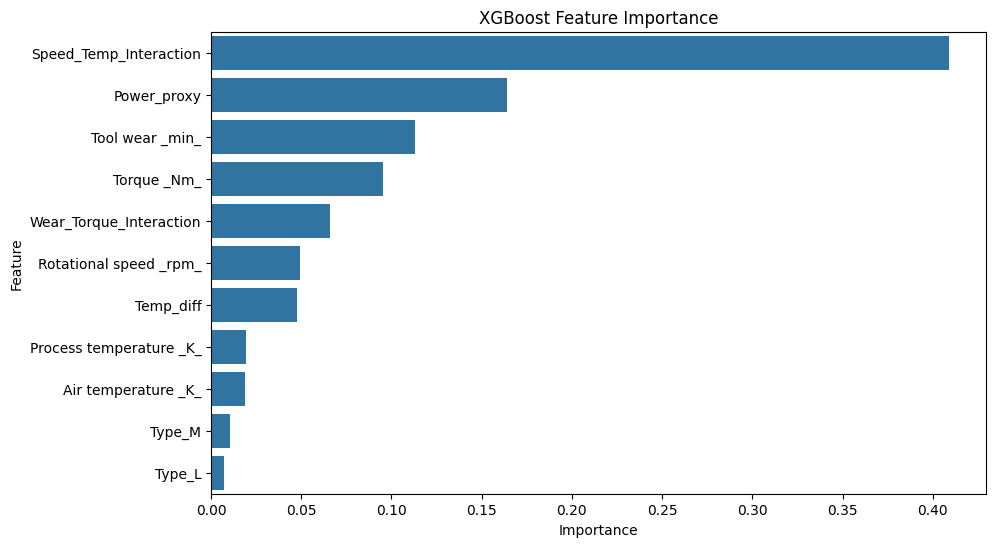

In [73]:
# ================================
# Feature Importance Plot
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('XGBoost Feature Importance')
plt.show()

In [74]:
pip install shap

In [75]:
import shap

In [76]:
explainer = shap.Explainer(xgb_model)

In [77]:
shap_values = explainer(X_test[:200])

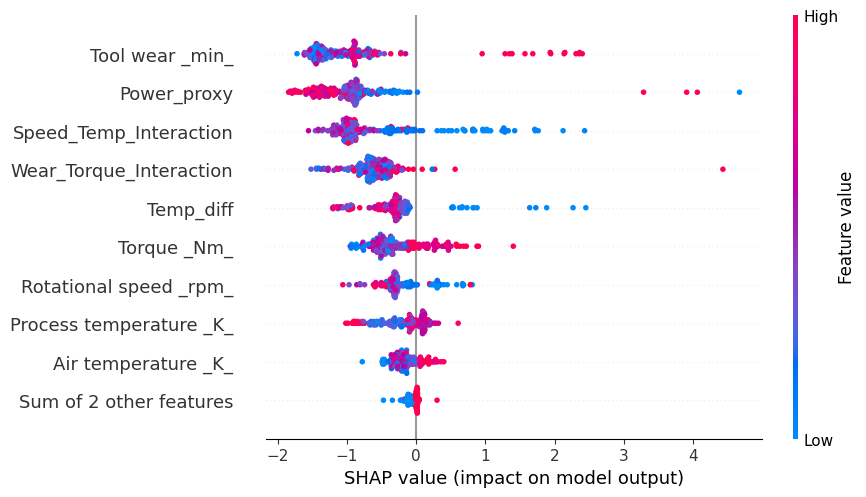

In [78]:
shap.plots.beeswarm(shap_values)

In [79]:
sample = X_test.iloc[[0]]

In [80]:
sample_shap = explainer(sample)

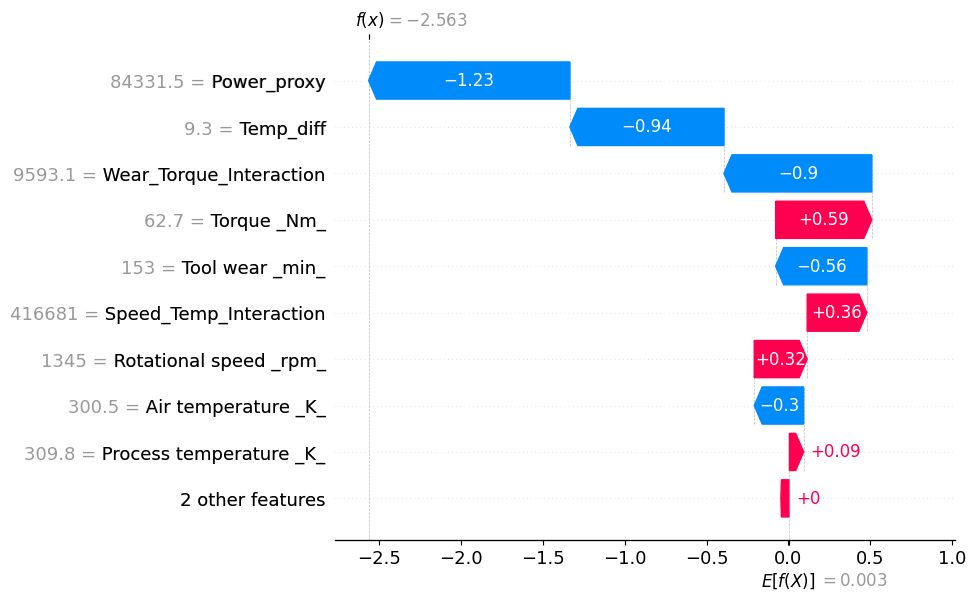

In [81]:
shap.plots.waterfall(sample_shap[0])

In [82]:
import pickle

In [84]:
# Save trained XGBoost model
import os

# Define the directory path
model_dir = '../models'

# Create the directory if it does not exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

with open(os.path.join(model_dir, 'xgb_model.pkl'), 'wb') as file:
    pickle.dump(xgb_model, file)

In [85]:
feature_columns = X_train.columns.tolist()

with open('../models/feature_columns.pkl', 'wb') as file:
    pickle.dump(feature_columns, file)

In [86]:
with open('../models/xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [87]:
import pickle

with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

In [88]:
feature_columns = X_train.columns.tolist()

with open('feature_columns.pkl', 'wb') as file:
    pickle.dump(feature_columns, file)

In [89]:
import os

os.listdir()

['.config',
 'xgb_model.pkl',
 'predictive_maintenance_raw.csv',
 'feature_columns.pkl',
 'sample_data']

In [90]:
from google.colab import files

files.download('xgb_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [91]:
files.download('feature_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>